# Linear Classifier on MNIST Dataset

In this notebook we will see a bunch of algorithms working on MNIST dataset.
This dataset is composed of $70,000$ single channels images ( $1 \times 28 \times 28$ pixels), representing the 10 numbers ($[0-9]$)

In order to avoid problems regarding memory issues, we will practically use a different version of this dataset, available at *sklearn* library, which consist of $\approx 1800$ images $8\times 8$

![alt_text](https://storage.googleapis.com/tfds-data/visualization/fig/mnist-3.0.1.png)

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns

from tqdm import tqdm

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

from skimage.feature import hog
from skimage.transform import resize

import matplotlib.pyplot as plt
%matplotlib inline

### LET'S GET THE DATASET

In [21]:
mnist = load_digits()
mnist

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

In [22]:
images = mnist['images']
target = mnist['target']
images.shape, target.shape  # X, y

((1797, 8, 8), (1797,))

<Figure size 640x480 with 0 Axes>

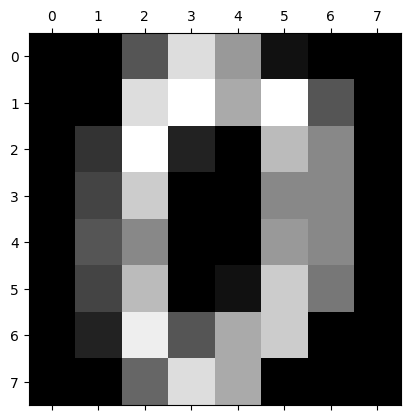

In [23]:
plt.gray()
plt.matshow(images[0])

### NOW LET'S EXTRACT LOCAL FEATURES OF THE IMAGES


The chose feature extraction method for this example is **HOG (Histogram of Oriented Gradients)**

An example on a high resolution image

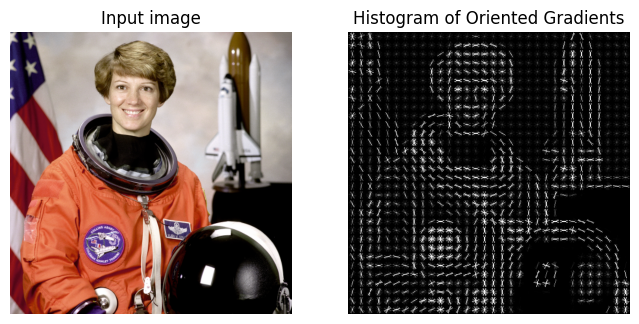

In [24]:
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import data, exposure


image = data.astronaut()

fd, hog_image = hog(image, orientations=8, pixels_per_cell=(16, 16),
                    cells_per_block=(1, 1), visualize=True, channel_axis=-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

In [25]:
hog_images = []
hog_features = []
for image in tqdm(images):
    feats, hog_image = hog(resize(image, (32, 32)),orientations=10, pixels_per_cell=(8, 8), cells_per_block= (2, 2), transform_sqrt=True, visualize=True)
    hog_images.append(hog_image)
    hog_features.append(feats)


100%|██████████| 1797/1797 [00:02<00:00, 888.59it/s]


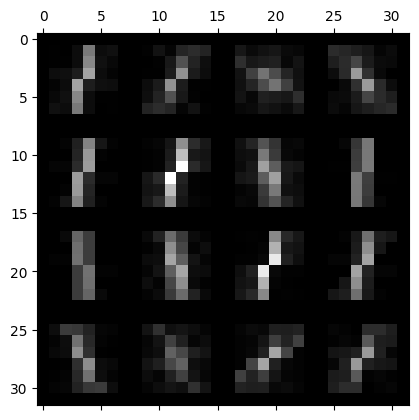

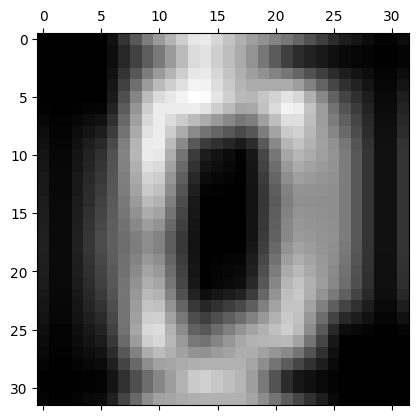

In [26]:
plt.matshow(hog_images[0])
plt.matshow(resize(images[0], (32, 32)))

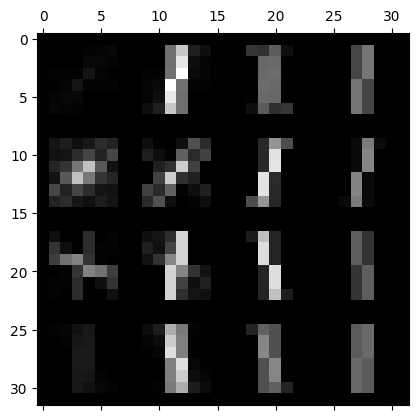

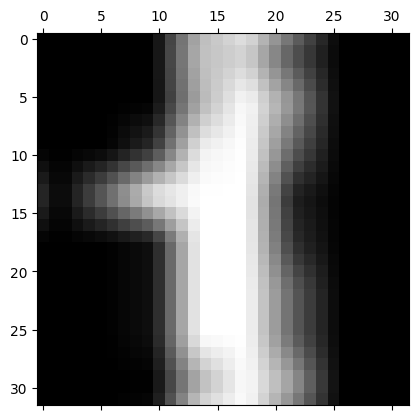

In [27]:
plt.matshow(hog_images[1])
plt.matshow(resize(images[1], (32, 32)))

In [28]:
print(f'{"Orginal flattened image dimesion:":<50}{hog_images[0].flatten().shape[0]:>10}')
print(f'{"Extracted feature vector dimension:":<50}{hog_features[0].shape[0]:>10}')
print(f'{"Space saved (%)":<50}{(1-(hog_features[1].shape[0] / hog_images[0].flatten().shape[0]))*100:>10.2f}')

Orginal flattened image dimesion:                       1024
Extracted feature vector dimension:                      360
Space saved (%)                                        64.84


In [29]:
print(f'we are saving {hog_features[1].shape[0] / hog_images[0].flatten().shape[0]:.2f}% of space')

we are saving 0.35% of space


In [30]:
hog_features=np.array(hog_features)
hog_features.shape

(1797, 360)

Now we can see in a 2 dimensional space how this new vectors are distributed

In [31]:
pca = PCA(n_components=0.8)
decomposed_mnist = pca.fit_transform(hog_features)
decomposed_mnist

array([[ 0.66465706, -0.04633201, -0.03787531, ..., -0.00955045,
        -0.10517434, -0.00999472],
       [ 0.32665085,  0.58132559,  0.13502172, ..., -0.26481676,
        -0.03450709, -0.116541  ],
       [ 0.24805507,  0.22699588,  0.16901713, ..., -0.04782816,
         0.28639557,  0.0599644 ],
       ...,
       [ 0.00214202,  0.19973178, -0.62386314, ...,  0.07371405,
         0.0257729 , -0.27001861],
       [-0.72184357, -0.31393368,  0.30991176, ..., -0.05800251,
         0.07883764,  0.00313714],
       [-0.32894878,  0.47260142, -0.53801836, ..., -0.07548635,
        -0.25423482,  0.02477787]], shape=(1797, 36))

In [32]:
decomposed_mnist = decomposed_mnist[:, :2]
decomposed_mnist

array([[ 0.66465706, -0.04633201],
       [ 0.32665085,  0.58132559],
       [ 0.24805507,  0.22699588],
       ...,
       [ 0.00214202,  0.19973178],
       [-0.72184357, -0.31393368],
       [-0.32894878,  0.47260142]], shape=(1797, 2))

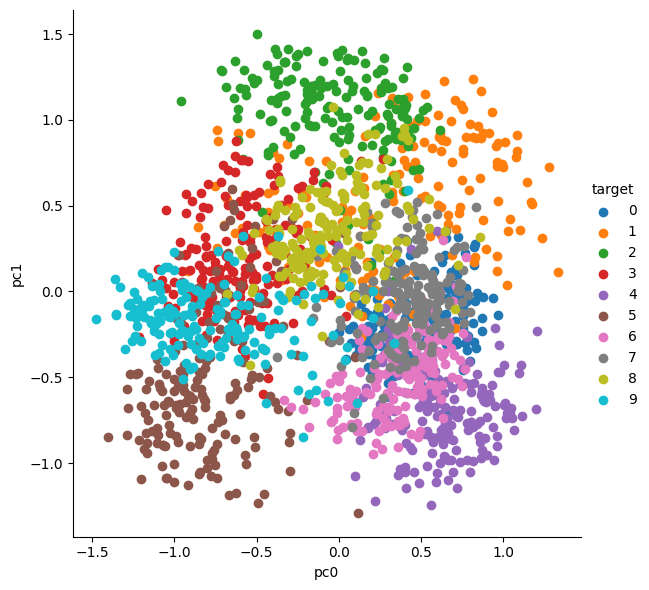

In [33]:
data_to_plot = pd.DataFrame(decomposed_mnist, columns=['pc0', 'pc1'])
data_to_plot['target'] = target
sns.FacetGrid(data_to_plot, hue='target', height=6).map(plt.scatter, 'pc0', 'pc1').add_legend()

Same models, different features

In [34]:
X_train, X_test, y_train, y_test = train_test_split(hog_features, target,
                                                    stratify=target,
                                                    random_state=41,
                                                    shuffle=True)

In [35]:
model = SGDClassifier(loss='log_loss',
                      penalty='l1',
                      random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'accuracy on test set: {accuracy:.4f}')

accuracy on test set: 0.9844


In [36]:
from sklearn.neighbors import KNeighborsClassifier

# compare other basic classifiers on the same data
models = []

#K-NN
models.append(('KNN with 7 neighbors', KNeighborsClassifier(n_neighbors=5)))

#linear classifier with cross-entropy loss
models.append(('SGD with cross-entropy loss', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.001)))

#linear classifier with hinge loss (SVM)
models.append(('SGD with hinge loss', SGDClassifier(loss='hinge', penalty='l2', alpha=0.001)))

models.append(('SVM', SVC(C=10, random_state=42)))

print('Accuracy on test set\n')
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name:<30}: {accuracy:.4f}')

Accuracy on test set

KNN with 7 neighbors          : 0.9889
SGD with cross-entropy loss   : 0.9822
SGD with hinge loss           : 0.9911
SVM                           : 0.9956


In [37]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10)

for name, model in models:
    cv_scores = cross_val_score(model, hog_features, target, cv=kf)
    print(f'{name:<30}: m={cv_scores.mean():.4f}, sd={cv_scores.std():.4f}')

KNN with 7 neighbors          : m=0.9744, sd=0.0160
SGD with cross-entropy loss   : m=0.9705, sd=0.0202
SGD with hinge loss           : m=0.9783, sd=0.0189
SVM                           : m=0.9878, sd=0.0116
